This notebooks contains all the analysis from the paper related to the coupled flow and heat transport problem **(Sequence A)**.
It loads the data from the `stats/` folder.

The headings in the notebook correspond to the sections of the paper.

In [1]:
from load_experiments_data import load_experiments_data_spe, make_pandas
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import seaborn as sns

font = 8
tex_fonts = {
    "font.family": "serif",
    "font.size": font,
    "axes.labelsize": font,
    "axes.titlesize": font,
    "xtick.labelsize": font,
    "ytick.labelsize": font,
    "legend.fontsize": font,
}

plt.rcdefaults()

sns.set_theme(
    context="paper",
    style="whitegrid",
    rc=tex_fonts,
)

ALL_RUNS = [200, 201, 202, 203, 204]
Path('figures/').mkdir(exist_ok=True)

# 6.1 Collecting Statistics

In [2]:
sim_data_random, perf_data_random, solver_selector = load_experiments_data_spe(
    runs=ALL_RUNS, case='random'
)
solver_space = solver_selector.solver_space
num_solvers = solver_space.all_decisions_encoding.shape[0]
print('Num solvers:', num_solvers)
print('Num category choices:', solver_space.num_category_choices)
print('Num numerical choices:', solver_space.num_numerical_choices)

Num solvers: 16575
Num category choices: 35
Num numerical choices: 16


In [3]:
df_sim_rand, df_perf_rand = make_pandas(
    sim_data=sim_data_random,
    perf_data=perf_data_random,
    seq_ids=ALL_RUNS,
)

df_perf_rand.head()

,seq_id,sim_idx,reward,expectation,decision_idx,features,predict_time,fit_time
0,200,0,-0.290237,100.0,12792,"[864.0, 393.0, 393.0, 1.4562886059610932e-14, ...",0.000297,0.000007
1,200,0,0.469212,100.0,8436,"[864.0, 141.96706364990018, 393.0000159752012,...",0.000343,0.000007
2,200,0,-200.000000,100.0,1440,"[864.0, 141.97506627589993, 617.0582745960949,...",0.000306,0.000006
3,200,0,-1.701191,100.0,14653,"[864.0, 141.97506627589993, 617.0582745960949,...",0.000320,0.000006
4,200,0,-0.197511,100.0,3669,"[864.0, 141.9968178324088, 841.6828525241965, ...",0.000307,0.000007


The cell below does this:
1. We store the performance data for each configuration separately;
2. We find the mean run time for each configuration;
3. We sort the configurations based on the mean run time and plot it.

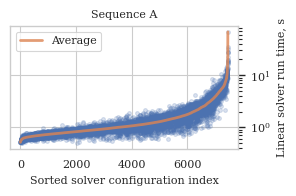

In [4]:
y_by_solver_id = [[] for _ in range(num_solvers)]
success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf_rand.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)
        y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

mean = []
std = []
for elem in y_by_solver_id:
    if len(elem) != 0:
        mean.append(np.mean(elem))
        std.append(np.std(elem))
    else:
        mean.append(np.nan)
        std.append(np.nan)

mean = np.array(mean)
std = np.array(std)

sorted_idx = np.argsort(mean)

idx = []
data = []
i = 0
for y in np.array(y_by_solver_id, dtype=object)[sorted_idx]:
    data.extend(y)
    idx.extend([i] * len(y))
    i += 1

plt.figure(figsize=(3,2))
plt.plot(mean[sorted_idx], color='C1', alpha=0.8, linewidth=2, label='Average')
plt.scatter(idx, data, marker='.', alpha=0.2, s=30)
# plt.ylim(1, 20)
# plt.yscale('log')
plt.grid(True)
plt.xlabel('Sorted solver configuration index')
plt.ylabel('Linear solver run time, s')
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.legend()
plt.title('Sequence A')
plt.yscale('log')
plt.tight_layout()

plt.savefig('figures/spe_sorted_run_times.png', dpi=600)

In [5]:
solver_selection_mean = 1.65  # this is the mean run time in the solver selection experiment (we get this number in Section 6.2, below)
print('The mean solver with solver selection corresponds to % best on the histogram above:', (mean[sorted_idx] < solver_selection_mean).sum() / mean.size * 100)

The mean solver with solver selection corresponds to % best on the histogram above: 35.203619909502265


Below, we compute statistics for the table in Section 6.1

In [6]:
num_always_success = 0
num_always_failure = 0
num_swinging = 0

for x in success_failure_by_solver_id:
    if len(x) == 0:
        continue
    elif np.all(x):
        num_always_success += 1
    elif not np.any(x):
        num_always_failure += 1
    else:
        num_swinging += 1

print(num_always_success, num_always_failure, num_swinging)

7253 4017 197


In [7]:
import pandas as pd

success = df_perf_rand.reward > -200
ysuccess = np.exp(-df_perf_rand[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'Num. solver configurations': [num_solvers],
    'Num. data points': df_perf_rand.shape[0],
    'Configurations tried, %': num_solvers_tried / num_solvers * 100,
    'Success rate, %': np.sum(success) / success.size * 100,
    'Always success, %': num_always_success / num_solvers_tried * 100,
    'Always failure, %': num_always_failure / num_solvers_tried * 100,
    # 'Swinging, %': num_swinging / num_solvers_tried * 100,
    'Run time average, s': ysuccess.mean(),
    'Run time median, s': ysuccess.median(),
    'Run time min, s': ysuccess.min(),
    'Run time max, s': ysuccess.max(),
}
pd.DataFrame(stats).T.round(2)

,0
Num. solver configurations,16575.00
Num. data points,19573.00
"Configurations tried, %",69.18
"Success rate, %",64.47
"Always success, %",63.25
"Always failure, %",35.03
"Run time average, s",1.51
"Run time median, s",1.01
"Run time min, s",0.49
"Run time max, s",67.79


# 6.2 Solver Selection Experiment

In [8]:
sim_data, perf_data, solver_selector = load_experiments_data_spe(
    runs=ALL_RUNS, case='solver_selection'
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim, df_perf = make_pandas(
    sim_data=sim_data,
    perf_data=perf_data,
    seq_ids=ALL_RUNS,
)
df_sim.head()

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl,simulation_dt,enthalpy_max,enthalpy_mean,fourier_max,fourier_mean
0,200,0,0,0,1.383387,54,2,1.456289e-14,864.0,3.903273e-07,9.789416e-10,4.547474e-13,1.968364e-14
1,200,0,0,1,0.670707,18,2,2.999172e-01,864.0,5.262662e+11,5.215374e+06,1.961152e+02,3.232768e-03
2,200,0,0,2,9.059947,10,2,2.993103e-01,864.0,1.935853e+11,2.701837e+06,3.657833e+02,2.059448e-02
3,200,0,0,3,1.258914,11,2,2.979907e-01,864.0,7.120052e+10,9.947021e+05,5.387129e+02,2.741988e-02
4,200,0,0,4,2.896911,14,2,2.940900e-01,864.0,2.617822e+10,3.680077e+05,5.888770e+02,2.965174e-02


Below, we compute statistics for the table in Section 6.2

In [9]:
y_by_solver_id = [[] for _ in range(num_solvers)]
success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)
        y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

num_always_success = 0
num_always_failure = 0
num_swinging = 0

for x in success_failure_by_solver_id:
    if len(x) == 0:
        continue
    elif np.all(x):
        num_always_success += 1
    elif not np.any(x):
        num_always_failure += 1
    else:
        num_swinging += 1

print(num_always_success, num_always_failure, num_swinging)

389 96 5


In [10]:
import pandas as pd

batch_size = 64
success = df_perf.reward > -200
ysuccess = np.exp(-df_perf[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'Num. solver configurations': [num_solvers],
    'Num. data points': df_perf.shape[0],
    'Configurations tried, %': num_solvers_tried / num_solvers * 100,
    'Success rate after init. expl., %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,  # [batch_size:] to kick out the initial exploration values 
    # '% num_always_success': num_always_success / num_solvers_tried * 100,
    # '% num_always_failure': num_always_failure / num_solvers_tried * 100,
    # '% num_swinging_success_failure': num_swinging / num_solvers_tried * 100,
    'Run time average, s': ysuccess.mean(),
    'Run time median, s': ysuccess.median(),
    'Run time min, s': ysuccess.min(),
    'Run time max, s': ysuccess.max(),
}
pd.DataFrame(stats).T.round(2)

,0
Num. solver configurations,16575.00
Num. data points,13042.00
"Configurations tried, %",2.96
"Success rate after init. expl., %",96.75
"Run time average, s",0.64
"Run time median, s",0.60
"Run time min, s",0.20
"Run time max, s",26.94


The cells below make various figures for Section 6.2

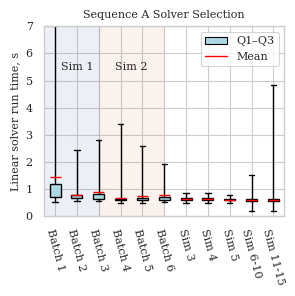

In [11]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

batches = range(6)
perf_data_per_batch = []

for bstart in batches:
    bend = bstart + 1
    tmp_list = []
    perf_data_per_batch.append(tmp_list)
    for seq_id in ALL_RUNS:
        tmp = df_perf[df_perf.seq_id == seq_id][bstart * batch_size : bend * batch_size]
        y = np.exp(-tmp.reward[tmp.reward > -200])
        tmp_list.extend(y.tolist())

sims = [[2], [3], [4], list(range(5,10)), list(range(10,15))]

for sim_id in sims:
    tmp = df_perf[df_perf.sim_idx.isin(sim_id)]
    y = np.exp(-tmp.reward[tmp.reward > -200])
    perf_data_per_batch.append(np.array(y))


plt.figure(figsize=(3, 3))
_ = plt.boxplot(
    perf_data_per_batch,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)


plt.axvspan(0, 3, alpha=0.1, color='C0')
plt.axvspan(3, 6, alpha=0.1, color='C1')
plt.xticks(
    range(1, len(perf_data_per_batch) + 1),
    [f'Batch {i+1}' for i in batches] + [f'Sim {x[0]+1}' if len(x)==1 else f'Sim {min(x)+1}-{max(x)+1}' for x in sims],
    rotation=-75
)
plt.text(2, 5.4, 'Sim 1', ha='center')
plt.text(4.5, 5.4, 'Sim 2', ha='center')

plt.xlim(left=0.5)

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Q1–Q3')
plt.legend(handles=[iqr_box, mean_line], loc='upper right')


# plt.xlabel("Batch number Sequence B")
plt.title('Sequence A Solver Selection')

plt.ylim(top=7, bottom=0)
plt.ylabel(r"Linear solver run time, s")
plt.tight_layout()
plt.savefig("figures/spe_boxplot_batches_and_simulations.png", dpi=600)

[441, 772, 873, 2041, 31]
Outliers, %: 0.7455507455507455


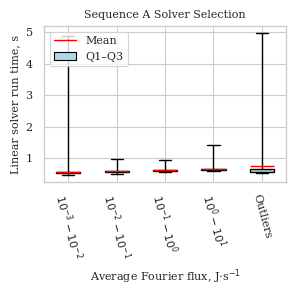

In [12]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

tmp = df_sim[df_sim.sim_idx.isin(range(10, 15))]
x = np.array(tmp.fourier_mean)
y = np.array(tmp.real_solve_time)
filter = (y < 30) & (y > 0.0002)  # drop failures and anomalies
x = x[filter]
y = y[filter]

bins = 10.0 ** np.arange(-3, 2)
perf_data_per_dt = []
xticklabels = []
for bin_start, bin_end in zip(bins[:-1], bins[1:]):
    perf_data_per_dt.append(y[(x >= bin_start) & (x < bin_end)])
    pow = int(np.log10(bin_start))
    xticklabels.append("$10^{" + str(pow) + "} - 10^{" + str(pow + 1) + "}$")
    # xticklabels.append(f'1e{pow}-1e{pow+1}')

# outliers
perf_data_per_dt.append(y[(x < bins[0]) | (x >= bins[-1])])
xticklabels.append("Outliers")

plt.figure(figsize=(3, 3))
plt.boxplot(
    perf_data_per_dt,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)
plt.xticks(np.arange(1, len(bins) + 1), xticklabels, rotation=-75)
plt.title("Sequence A Solver Selection")

# plt.ylim(top=7, bottom=0)
plt.xlabel('Average Fourier flux, J$\cdot$s$^{-1}$')
plt.ylabel(r"Linear solver run time, s")

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Q1–Q3')
plt.legend(handles=[mean_line, iqr_box], loc='upper left')
# plt.ylim(top=4)

plt.tight_layout()
plt.savefig("figures/spe_boxplot_fourier.png", dpi=600)

print([len(x) for x in perf_data_per_dt])
print('Outliers, %:', len(perf_data_per_dt[-1]) / sum([len(x) for x in perf_data_per_dt]) * 100)

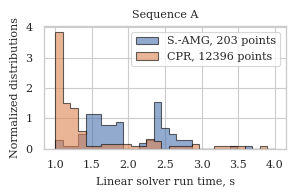

In [13]:
from solver_selection_thm.solver_space import explain_decisions

solver_space = solver_selector.solver_space
decision_names, decision_ranges = explain_decisions(solver_space)


perf_dict_for_pandas = []
for row in df_perf.itertuples(index=False):
    decision_vec = solver_space.all_decisions_encoding[row.decision_idx]
    perf_dict_for_pandas.append(
        {name: val for name, val in zip(decision_names, decision_vec)}
    )

column_dtypes = {x: bool for x in decision_names[:solver_space.num_category_choices]} 
column_dtypes |= {x: float for x in decision_names[solver_space.num_category_choices:]} 
tmp = pd.DataFrame(perf_dict_for_pandas).astype(column_dtypes)

df_perf_detailed = pd.concat([df_perf, tmp], axis=1)
df_perf_detailed['time'] = np.exp(-df_perf_detailed.reward)
df_perf_detailed = df_perf_detailed.drop('features', axis=1)
df_perf_detailed

def make_hist(df: pd.DataFrame, label: str):
    bins = 30
    bins = np.linspace(1, 4, bins, endpoint=True)
    y = df.reward[df.reward > -200]
    y = np.exp(-y)
    plt.hist(y, label=f'{label}, {y.size} points', alpha=0.6, bins=bins, density=True, edgecolor="black", histtype='stepfilled')

plt.figure(figsize=(3,2))
make_hist(df_perf_detailed[df_perf_detailed['PetscFieldSplitScheme'] == True], label='S.-AMG')
make_hist(df_perf_detailed[df_perf_detailed['PetscCompositeScheme'] == True], label='CPR')
plt.ylabel('Normalized distributions')
plt.xlabel('Linear solver run time, s')
plt.title('Sequence A')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/spe_system_amg_vs_cpr.png', dpi=600)

Mean selection overhead, s: 0.006170308082958613 +- 0.0009970301190102928


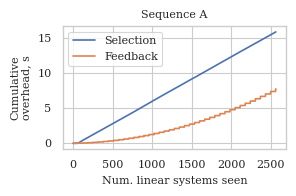

In [14]:
plt.figure(figsize=(3,2))
selection_overhead = np.array(df_perf[df_perf.seq_id == ALL_RUNS[4]].predict_time)
feedback_overhead = np.array(df_perf[df_perf.seq_id == ALL_RUNS[4]].fit_time)
plt.plot(np.cumsum(selection_overhead), label='Selection')
plt.plot(np.cumsum(feedback_overhead), label='Feedback')
plt.legend()
plt.ylabel('Cumulative\noverhead, s')
plt.xlabel('Num. linear systems seen')
plt.title('Sequence A')
plt.tight_layout()
plt.savefig('figures/spe_ml_overhead.png', dpi=600)
print('Mean selection overhead, s:', selection_overhead.mean(), '+-', selection_overhead.std())

4 117


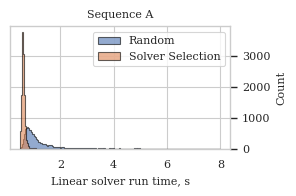

In [15]:
data = np.exp(-df_perf.reward[df_perf.reward > -200])
data_rand = np.exp(-df_perf_rand.reward[df_perf_rand.reward > -200])

bins = 200
upper_lim = 8
bins = np.linspace(min(data_rand), upper_lim, bins)
plt.figure(figsize=(3,2))
plt.hist(data_rand, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Random', histtype='stepfilled')
plt.hist(data, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Solver Selection', histtype='stepfilled')

plt.xlabel("Linear solver run time, s")
plt.ylabel("Count")
plt.legend()
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.title('Sequence A')
plt.tight_layout()
plt.savefig('figures/spe_runtime_histogram.png', dpi=600)

print(np.sum(data > upper_lim), np.sum(data_rand > upper_lim))

# 6.3 Comparing Againts Optimal Solver

In [16]:
sim_data_expert, perf_data_expert, solver_selector = load_experiments_data_spe(
    runs=ALL_RUNS, case='expert'
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim_expert, df_perf_expert = make_pandas(
    sim_data=sim_data_expert,
    perf_data=perf_data_expert,
    seq_ids=ALL_RUNS,
)
df_sim_expert.tail()

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl,simulation_dt,enthalpy_max,enthalpy_mean,fourier_max,fourier_mean
12620,204,14,50,1,0.639922,18,2,58698.390467,8.640000e+07,3.279322e+06,1084.947283,258.236507,3.682364
12621,204,14,50,2,0.606775,17,2,58698.390467,8.640000e+07,3.279322e+06,1084.947388,258.236505,3.682361
12622,204,14,51,0,0.622320,18,2,32952.513761,4.850384e+07,3.279322e+06,1084.947388,258.236505,3.682361
12623,204,14,51,1,0.623264,18,2,32952.513759,4.850384e+07,3.279322e+06,1084.550519,258.266719,3.680157
12624,204,14,51,2,0.606892,17,2,32952.513759,4.850384e+07,3.279322e+06,1084.550543,258.266719,3.680156


In [17]:
import pandas as pd

success = df_perf_expert.reward > -200
ysuccess = np.exp(-df_perf_expert[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)  # TODO!

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf_expert.shape[0],
    '% solvers_tried': num_solvers_tried / num_solvers * 100,
    'Success %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,16575.000000
num_points,12620.000000
% solvers_tried,2.956259
Success %,100.000000
Run time avg,0.589657
Run time median,0.592918
Run time min,0.458164
Run time max,2.229331


In [18]:
sim_data_petsc_default, perf_data_petsc_default, _ = load_experiments_data_spe(
    runs=ALL_RUNS, case='petsc_default'
)

df_sim_petsc_default, df_perf_petsc_default = make_pandas(
    sim_data=sim_data_petsc_default,
    perf_data=perf_data_petsc_default,
    seq_ids=ALL_RUNS,
)
df_sim_petsc_default.tail()

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl,simulation_dt,enthalpy_max,enthalpy_mean,fourier_max,fourier_mean
12620,204,14,50,1,1.097682,13,2,58698.390467,8.640000e+07,3.279322e+06,1084.947283,258.236507,3.682364
12621,204,14,50,2,1.120340,13,2,58698.390467,8.640000e+07,3.279322e+06,1084.947388,258.236505,3.682361
12622,204,14,51,0,1.095121,13,2,32952.513761,4.850384e+07,3.279322e+06,1084.947388,258.236505,3.682361
12623,204,14,51,1,1.107571,13,2,32952.513759,4.850384e+07,3.279322e+06,1084.550519,258.266719,3.680157
12624,204,14,51,2,1.134815,13,2,32952.513759,4.850384e+07,3.279322e+06,1084.550543,258.266719,3.680156


In [19]:
import pandas as pd

success = df_perf_petsc_default.reward > -200
ysuccess = np.exp(-df_perf_petsc_default[success].reward)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf_expert.shape[0],
    'Success %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,16575.000000
num_points,12620.000000
Success %,99.209549
Run time avg,0.975585
Run time median,0.979495
Run time min,0.758264
Run time max,1.215621


Mean run time random: 12338.074388551711
Mean run time solver_selection 2253.5581167697906
Mean run time petsc default: 2557.251440858841
Mean run time expert: 1826.5779748439788


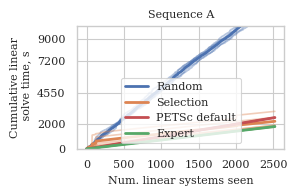

In [20]:
from scipy.interpolate import interp1d

plt.figure(figsize=(3,2))

resampled = []
for seq_id in ALL_RUNS:
    y = np.array(df_sim_rand.real_solve_time[df_sim_rand.seq_id == seq_id])
    y = np.cumsum(y)

    plt.plot(y, color="C0", alpha=0.4)

    x_old = np.arange(y.size)
    f = interp1d(x_old, y, kind="linear")
    x_new = np.linspace(0, len(x_old) - 1, 2600, endpoint=True)
    resampled.append(f(x_new))
print('Mean run time random:', np.mean(resampled, axis=0).max())

plt.plot(x_new, np.mean(resampled, axis=0), color="C0", linewidth=2, label='Random', alpha=1)

resampled = []
for seq_id in ALL_RUNS:
    y = np.array(df_sim.real_solve_time[df_sim.seq_id == seq_id])
    y = np.cumsum(y)

    plt.plot(y, color="C1", alpha=0.4)

    x_old = np.arange(y.size)
    f = interp1d(x_old, y, kind="linear")
    x_new = np.linspace(0, len(x_old) - 1, 2600, endpoint=True)
    resampled.append(f(x_new))

plt.plot(x_new, np.mean(resampled, axis=0), color="C1", linewidth=2, label='Selection', alpha=1)
print('Mean run time solver_selection', np.mean(resampled, axis=0).max())

resampled = []
for seq_id in ALL_RUNS:
    y = np.array(df_sim_petsc_default.real_solve_time[df_sim_petsc_default.seq_id == seq_id])
    y = np.cumsum(y)

    plt.plot(y, color="C3", alpha=0.4)

    x_old = np.arange(y.size)
    f = interp1d(x_old, y, kind="linear")
    x_new = np.linspace(0, len(x_old) - 1, 2600, endpoint=True)
    resampled.append(f(x_new))

plt.plot(x_new, np.mean(resampled, axis=0), color="C3", linewidth=2, label='PETSc default', alpha=1)
print('Mean run time petsc default:', np.mean(resampled, axis=0).max())

resampled = []
for seq_id in ALL_RUNS:
    y = np.array(df_sim_expert.real_solve_time[df_sim_expert.seq_id == seq_id])
    y = np.cumsum(y)

    plt.plot(y, color="C2", alpha=0.4)

    x_old = np.arange(y.size)
    f = interp1d(x_old, y, kind="linear")
    x_new = np.linspace(0, len(x_old) - 1, 2600, endpoint=True)
    resampled.append(f(x_new))

plt.plot(x_new, np.mean(resampled, axis=0), color="C2", linewidth=2, label='Expert', alpha=1)
print('Mean run time expert:', np.mean(resampled, axis=0).max())



plt.yticks([0, 2000, 4550, 7200, 9000])


plt.ylabel('Cumulative linear\n solve time, s')
plt.xlabel('Num. linear systems seen')
plt.legend(loc='lower center')
plt.title('Sequence A')

plt.ylim(bottom=0, top=10000)

plt.tight_layout()
plt.savefig('figures/spe_runtime_expert.png', dpi=600)

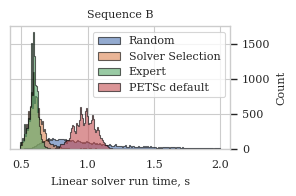

In [21]:
data = np.exp(-df_perf.reward[df_perf.reward > -200])
data_rand = np.exp(-df_perf_rand.reward[df_perf_rand.reward > -200])
data_expert = np.exp(-df_perf_expert.reward[df_perf_expert.reward > -200])
data_petsc_default = np.exp(-df_perf_petsc_default.reward[df_perf_petsc_default.reward > -200])

bins = 200
upper_lim = 2
bins = np.linspace(min(data_rand), upper_lim, bins)
plt.figure(figsize=(3,2))
plt.hist(data_rand, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Random', histtype='stepfilled')
plt.hist(data, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Solver Selection', histtype='stepfilled')
plt.hist(data_expert, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Expert', histtype='stepfilled')
plt.hist(data_petsc_default, bins=bins, density=False, alpha=0.6, edgecolor="black", label='PETSc default', histtype='stepfilled')


plt.xlabel("Linear solver run time, s")
plt.ylabel("Count")
plt.legend()
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.title('Sequence B')
plt.tight_layout()

# How many bad solvers?

How many congifurations correspond to the "naive" group?

In [22]:
import pandas as pd
from solver_selection_thm.solver_space import explain_decisions

solver_space = solver_selector.solver_space
decision_names, decision_ranges = explain_decisions(solver_space)
decision_names

['PetscFieldSplitScheme - ilu',
 'PetscFieldSplitScheme',
 'PetscFieldSplitScheme - sor',
 'PetscFieldSplitScheme - pbjacobi',
 'PetscFieldSplitScheme - hypre - symmetric-SOR/Jacobi',
 'PetscFieldSplitScheme - hypre - V',
 'PetscFieldSplitScheme - hypre',
 'PetscFieldSplitScheme - hypre - W',
 'PetscFieldSplitScheme - hypre - l1scaled-Jacobi',
 'PetscFieldSplitScheme - hypre - SOR/Jacobi',
 'PetscFieldSplitScheme - hypre - Jacobi',
 'PetscFieldSplitScheme - gamg - V',
 'PetscFieldSplitScheme - gamg - sor',
 'PetscFieldSplitScheme - gamg',
 'PetscFieldSplitScheme - gamg - pbjacobi',
 'PetscFieldSplitScheme - gamg - W',
 'PetscCompositeScheme - hypre - symmetric-SOR/Jacobi',
 'PetscCompositeScheme - hypre - V',
 'PetscCompositeScheme - hypre',
 'PetscCompositeScheme - sor',
 'PetscCompositeScheme - ilu',
 'PetscCompositeScheme',
 'PetscCompositeScheme - sor',
 'PetscCompositeScheme - pbjacobi',
 'PetscCompositeScheme - jacobi',
 'PetscCompositeScheme - none',
 'PetscCompositeScheme - hyp

In [23]:
num_with_ilu = (solver_space.all_decisions_encoding[:, 0] == True).sum()
num_with_sor = (solver_space.all_decisions_encoding[:, 2] == True).sum()
num_with_pbjacobi = (solver_space.all_decisions_encoding[:, 3] == True).sum()
total = solver_space.all_decisions_encoding.shape[0]
print(f'{num_with_ilu = }, {num_with_sor = }, {num_with_pbjacobi = }, {total = }')
print(num_with_ilu + num_with_sor + num_with_pbjacobi)
print((num_with_ilu + num_with_sor + num_with_pbjacobi) / total * 100, '%')

num_with_ilu = 9, num_with_sor = 3, num_with_pbjacobi = 3, total = 16575
15
0.09049773755656108 %
